# TACTIC Validations
This notebook contains the code used to process and analyze all experimental validation data for the TACTIC manuscript.

## 0. Set Up Environment
Import dependencies, load datasets, and define custome functions.

### 0.1 Import dependencies

In [1]:
# Import dependencies
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import warn
from urllib.request import urlopen

### 0.2 Load experimental data

In [2]:
# Instantiate data variable
data = dict()

#### 0.2.1 Collaborator: Brunaugh (P. aeruginosa)

In [3]:
# Instantiate container
data['Brunaugh'] = dict()

# Import data
df = pd.read_csv('./data/Endophthalmitis/Brunaugh_SynergyFinder_input.csv')

# Define IDs
df['ID'] = df[['Sample', 'Drug1', 'Drug2']].apply(lambda x: ', '.join(x.values.tolist()), axis=1)

# Save data
data['Brunaugh']['raw'] = df.copy()

#### 0.2.2 Collaborator: Karthik (P. aeruginosa and S. aureus)

In [4]:
# Instantiate container
data['Karthik'] = dict()

# Import data
df = pd.read_csv('./data/Endophthalmitis/Karthik_SynergyFinder_input_validation.csv')

# Define IDs
df['ID'] = df[['Sample', 'Drug1', 'Drug2']].apply(lambda x: ', '.join(x.values.tolist()), axis=1)

# Save data
data['Karthik']['raw'] = df.copy()

In [5]:
# Load all data
df = pd.read_csv('./data/Endophthalmitis/Karthik_SynergyFinder_input.csv')

# Define IDs
df['ID'] = df[['Sample', 'Drug1', 'Drug2']].apply(lambda x: ', '.join(x.values.tolist()), axis=1)

# Save data
data['Karthik']['all'] = df.copy()

### 0.3 Define custom functions

#### 0.3.1 Interaction scoring function

In [6]:
# Define score function
def calculate_scores(data, threshold=0.2, mask:bool=True, aggregate:str='mean'): 
    
    '''Calculate interaction scores based on the Loewe Additivity or Bliss Independence model.'''

    # Loop through each unique combination
    d_dict, b_dict, l_dict = dict(), dict(), dict()
    s_list, i_list, b_list = list(), list(), list()
    for id in data['ID'].unique(): 
        # Extract info from ID
        strain, da, db = id.split(', ')
        s_list.append(strain)
        i_list.append('-'.join([da, db]))
        # Filter dataframe by ID and pivot
        df = data[data['ID']==id].pivot(index='Conc1', columns='Conc2')['Response']
        # Process matrix (interpolate and divide by 100)
        df = df.interpolate(method='linear').div(100)
        d_dict[id] = df.copy()
        # Extract single drug growth values and combination matrix
        ga, gb, dfc = df.iloc[1:, 0], df.iloc[0, 1:], df.iloc[1:, 1:]
        # Determine board type
        ta, tb = 0.5, 0.5
        # ta, tb = 1-threshold, 1-threshold
        # ta, tb = 1-threshold+ga.min(), 1-threshold+gb.min()
        # diffa, diffb = ga.max()-ga.min(), gb.max()-gb.min()
        diffa, diffb = ga.iloc[0]-ga.iloc[-1], gb.iloc[0]-gb.iloc[-1]
        if (diffa > ta) and (diffb > tb): 
            b_list.append('Double effect')
        elif (diffa > ta) or (diffb > tb): 
            b_list.append('Single effect')
        else: 
            b_list.append('No effect')
        # Calculate Bliss scores
        b_dict[id] = dfc - (np.add(np.tile(gb, (len(ga), 1)), ga.values.reshape(-1, 1)) - np.outer(ga, gb))
        # Mask non-interactions (if prompted)
        if mask: 
            dfi = pd.DataFrame(np.outer(ga, gb), index=dfc.index, columns=dfc.columns)
            b_dict[id] = b_dict[id].mask(dfi.abs() < 0.01)
        # Calculate Loewe scores
        if (df >= threshold).all(axis=None): 
            warn('{:.0%} inhibition not observed for {} + {} on {}'.format(1-threshold, da, db, strain))
            l_dict[id] = [np.nan]
        else: 
            if (ga >= threshold).all() or (gb >= threshold).all() or (dfc >= threshold).all(axis=None): 
                warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))
                l_dict[id] = [np.nan]
            else: 
                # Determine MIC values
                mic_a, mic_b = ga[ga < threshold].index[-1], gb[gb < threshold].index[-1]
                # Calculate Loewe scores
                ix, jx = np.where(dfc < threshold)
                l_dict[id] = [np.log2(dfc.index[i]/mic_a + dfc.columns[j]/mic_b) for i, j in zip(ix, jx)]

    # Define output
    df_out = pd.DataFrame({
        'Label': d_dict.keys(), 
        'Strain': s_list, 
        'Interaction': i_list, 
        'Board type': b_list, 
        'Bliss score (Manual)': [x.mean(axis=None) if aggregate=='mean' else x.median(axis=None) for x in b_dict.values()], 
        'Loewe score (Manual)': [sum(x)/len(x) for x in l_dict.values()]
    })
    return df_out, d_dict, b_dict

#### 0.3.2 Checkerboard visualization function

In [7]:
# Define plotting function
def visualize_checkerboard(label, annot:bool=True, fmt:str='.1f', cmap:str='Greens', flip:bool=False): 
    
    'Visualize a checkerboard (i.e., dose-response matrix) as a heatmap.'

    # Extract metadata
    if flip: 
        strain, drug1, drug2 = label.split(', ')
        ixn = '-'.join([drug1, drug2])
        board = d_dict[label].copy().T
    else: 
        strain, drug2, drug1 = label.split(', ')
        ixn = '-'.join([drug2, drug1])
        board = d_dict[label].copy()

    # Define heatmap plot inputs
    m, n = board.shape
    board = board.reindex(index=board.index[::-1])
    control = np.array(board.iloc[-1, 0]).reshape((1, 1))
    d1_vector = board.iloc[-1, 1:].values.reshape((1, n-1))
    d2_vector = board.iloc[:-1, 0].values.reshape((m-1, 1))
    dr_matrix = board.iloc[:-1, 1:].values
    xlab = board.columns[1:].values.astype(str).reshape(n-1)
    ylab = board.index[:-1].values.astype(str).reshape(m-1)
    vmin, vmax = 0, board.max(axis=None)

    # Define scatter plot inputs
    s = score_df[score_df['Label']==label]
    df = pd.DataFrame({
        'Method': ['Manual', 'SynergyFinder'], 
        'Bliss score': s['Bliss score (Manual)'].tolist() + s['Bliss score (SynergyFinder)'].tolist(), 
        'Loewe score': s['Loewe score (Manual)'].tolist() + s['Loewe score (SynergyFinder)'].tolist()
    })

    # Set figure specs
    fig = plt.figure(figsize=(10, 4), layout='constrained')
    gs = fig.add_gridspec(2, 4, width_ratios=[0.1, 1, 0.1, 0.8], height_ratios=[0.7, 0.1])

    # Plot positive control
    ax = fig.add_subplot(gs[1, 0])
    sns.heatmap(control, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.set_xticklabels(labels=['0.0'])
    ax.set_yticklabels(labels=['0.0'], rotation=0)

    # Plot drug 1 inhibition (x-axis)
    ax = fig.add_subplot(gs[1, 1])
    sns.heatmap(d1_vector, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.tick_params(left=False, bottom=False)
    ax.set(yticklabels=[])
    ax.set_xticklabels(labels=xlab, rotation=20)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    ax.set_xlabel('[{}] (ug/mL)'.format(drug1))

    # Plot drug 2 inhibition (y-axis)
    ax = fig.add_subplot(gs[0, 0])
    sns.heatmap(d2_vector, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar=False, ax=ax)
    ax.tick_params(left=False, bottom=False)
    ax.set(xticklabels=[])
    ax.set_yticklabels(labels=ylab, rotation=0)
    for _, spine in ax.spines.items():
        spine.set_visible(True)
    ax.set_ylabel('[{}] (ug/mL)'.format(drug2))

    # Plot dose-response matrix
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[0, 2])
    sns.heatmap(dr_matrix, annot=annot, fmt=fmt, cmap=cmap, vmin=vmin, vmax=vmax, cbar_ax=ax2, ax=ax1)
    ax1.tick_params(left=False, bottom=False)
    ax1.set(xticklabels=[], yticklabels=[])
    for _, spine in ax1.spines.items():
        spine.set_visible(True)
    ax1.set_title('{}, {}'.format(strain, ixn), fontsize=12)
    ax2.set_title('Viability', fontsize=10)

    # Plot focused scatter plot
    ax = fig.add_subplot(gs[:, 3])
    sns.scatterplot(data=df, x='Bliss score', y='Loewe score', hue='Method', s=100, ax=ax)
    ax.axhline(0, ls='--', color='k')
    ax.axvline(0, ls='--', color='k')
    ax.set_title('Manual vs. SynergyFinder scores')

    # Assign whitespace to unused axis
    ax = fig.add_subplot(gs[1, 2])
    ax.axis('off')

    # Show figure
    fig.show()

## 1. Brunaugh data analysis

Process and analyze data measured by the Brunaugh group.

In [8]:
# Define raw data
df = data['Brunaugh']['raw'].copy()

# Manually calculate scores
dfo, d_dict, _ = calculate_scores(df)

# Add SynergyFinder scores
df = pd.read_excel('./data/Endophthalmitis/Brunaugh_SynergyFinder_output.xlsx', sheet_name='all', engine='openpyxl')
dfo['Bliss score (SynergyFinder)'] = -df['Bliss score'].copy()
dfo['Loewe score (SynergyFinder)'] = -df['Loewe score'].copy()

# Save processed data
data['Brunaugh']['processed'] = dfo.copy().fillna(value=0.)
data['Brunaugh']['boards'] = d_dict.copy()

C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for AMP + CLA on Smooth
  warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))
C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:41: UserWarning: 80% inhibition not observed for AMP + CLA-MEC on Smooth
  warn('{:.0%} inhibition not observed for {} + {} on {}'.format(1-threshold, da, db, strain))
C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for AMP + CLA-MEC on Rough
  warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))
C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for AMX + CFX on PS4
  warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))


In [9]:
# Import dependencies
import ipywidgets
from IPython.display import display

# Source-specific inputs
d_dict = data['Brunaugh']['boards'].copy()
score_df = data['Brunaugh']['processed'].copy()
b_list = list(d_dict.keys())

# Create interactive menus
style = {'description_width': 'initial'}
labels = ipywidgets.Dropdown(
    options=b_list, 
    value=b_list[0], 
    description='Select checkerboard: ', 
    style=style
)
annotate = ipywidgets.Checkbox(
    value=True, 
    description='Annotate boxes', 
    indent=False, 
    style=style
)
cmap = ipywidgets.Dropdown(
    options=['Greens', 'Blues', 'Reds', 'Purples', 'Oranges', 'Greys'], 
    value='Greens', 
    description='Select colormap: ', 
    style=style
)
flip = ipywidgets.Checkbox(
    value=True, 
    description='Flip checkerboard: ', 
    indent=False, 
    style=style
)

# Define UI
ui = ipywidgets.HBox([labels, cmap, annotate])

# Define output
out = ipywidgets.interactive_output(visualize_checkerboard, {'label': labels, 'annot': annotate, 'cmap': cmap, 'flip': flip})

# Display plot
display(ui, out)

Output()

## 2. Karthik data analysis

Process and analyze data measured by Karthik's group.

In [10]:
# Define raw data
df = data['Karthik']['raw'].copy()

# Manually calculate scores
dfo, d_dict, _ = calculate_scores(df)

# Add SynergyFinder scores
df = pd.read_excel('./data/Endophthalmitis/Karthik_SynergyFinder_output.xlsx', sheet_name='validation', engine='openpyxl')
dfo['Bliss score (SynergyFinder)'] = -df['Bliss score'].copy()
dfo['Loewe score (SynergyFinder)'] = -df['Loewe score'].copy()

# Save processed data
data['Karthik']['processed'] = dfo.copy().fillna(value=0.).sort_values(by=['Strain', 'Interaction'])
data['Karthik']['boards'] = d_dict.copy()

C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for DXR + PMS on SA
  warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))
C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for CCCP + DOX on SA
  warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))
C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for CET + MOX on PS
  warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))


In [11]:
# Determine scores and boards for all data
df = data['Karthik']['all'].copy()
dfo, d_dict, _ = calculate_scores(df)

# Add SynergyFinder scores
df = pd.read_excel('./data/Endophthalmitis/Karthik_SynergyFinder_output.xlsx', sheet_name='all', engine='openpyxl')
dfo['Bliss score (SynergyFinder)'] = -df['Bliss score'].copy()
dfo['Loewe score (SynergyFinder)'] = -df['Loewe score'].copy()

# Save processed data
data['Karthik']['all_processed'] = dfo.copy().fillna(value=0.).sort_values(by=['Strain', 'Interaction'])
data['Karthik']['all_boards'] = d_dict.copy()

C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:41: UserWarning: 80% inhibition not observed for A22 + DXR on PS_ATCC
  warn('{:.0%} inhibition not observed for {} + {} on {}'.format(1-threshold, da, db, strain))
C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for A22 + DXR on SA_ATCC
  warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))
C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for A22 + DXR on PS
  warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))
C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for A22 + DXR on SA
  warn('Could not calculate Loewe score for {} + {} on {}'.format(da, db, strain))
C:\Users\carol\AppData\Local\Temp\ipykernel_21612\727654183.py:45: UserWarning: Could not calculate Loewe score for A22 + 

In [12]:
# Import dependencies
import ipywidgets
from IPython.display import display

# Source-specific inputs
d_dict = data['Karthik']['boards'].copy()
score_df = data['Karthik']['processed'].copy()
b_list = sorted(list(d_dict.keys()))

# Create interactive menus
style = {'description_width': 'initial'}
labels = ipywidgets.Dropdown(
    options=b_list, 
    value=b_list[0], 
    description='Select checkerboard: ', 
    style=style
)
annotate = ipywidgets.Checkbox(
    value=True, 
    description='Annotate boxes', 
    indent=False, 
    style=style
)
cmap = ipywidgets.Dropdown(
    options=['Greens', 'Blues', 'Reds', 'Purples', 'Oranges', 'Greys'], 
    value='Greens', 
    description='Select colormap: ', 
    style=style
)
flip = ipywidgets.Checkbox(
    value=False, 
    description='Flip checkerboard: ', 
    indent=False, 
    style=style
)

# Define UI
ui = ipywidgets.HBox([labels, cmap, annotate])

# Define output
out = ipywidgets.interactive_output(visualize_checkerboard, {'label': labels, 'annot': annotate, 'cmap': cmap, 'flip': flip})

# Display plot
display(ui, out)

Output()

## 3. Visual inspections

In [13]:
# Combine data
df1, df2 = data['Brunaugh']['processed'].copy(), data['Karthik']['processed'].copy()
df1['Source'] = 'Brunaugh'
df2['Source'] = 'Karthik'
dfo = pd.concat([df1, df2], ignore_index=True)

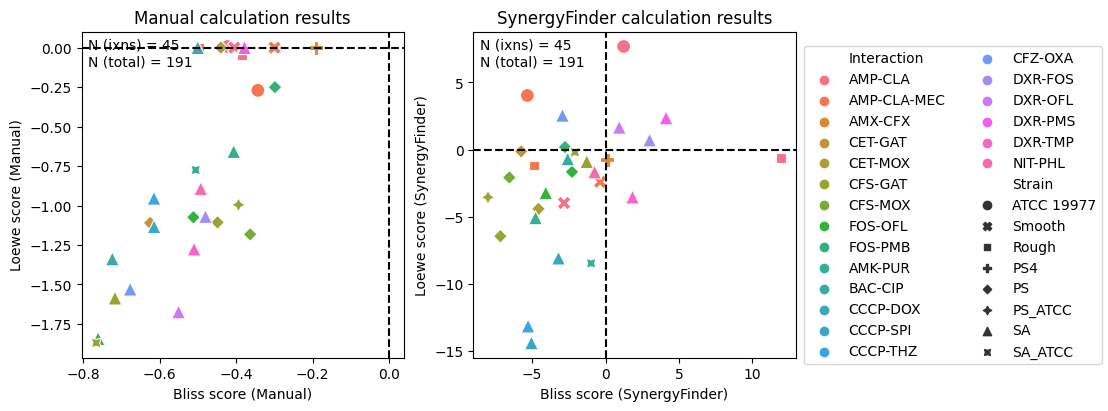

In [14]:
# Instantiate figure
n = 2
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(4 + 4 + 1.5*n, 4), constrained_layout=True)
fig.set_facecolor('white')

# Plot manual scatter
ax, method = axs[0], 'Manual'
x, y = 'Bliss score ({})'.format(method), 'Loewe score ({})'.format(method)
sns.scatterplot(data=dfo, x=x, y=y, hue='Interaction', style='Strain', s=100, ax=ax)
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
ax.set_title('{} calculation results'.format(method))
ax.text(0.02, 0.98, 'N (ixns) = {}\nN (total) = {}'.format(len(df['Interaction'].unique()), df.shape[0]), 
    ha='left', va='top', transform=ax.transAxes)
ax.legend().remove()

# Plot SynergyFinder scatter
ax, method = axs[1], 'SynergyFinder'
x, y = 'Bliss score ({})'.format(method), 'Loewe score ({})'.format(method)
sns.scatterplot(data=dfo, x=x, y=y, hue='Interaction', style='Strain', s=100, ax=ax)
ax.axhline(0, ls='--', color='k')
ax.axvline(0, ls='--', color='k')
ax.set_title('{} calculation results'.format(method))
ax.text(0.02, 0.98, 'N (ixns) = {}\nN (total) = {}'.format(len(df['Interaction'].unique()), df.shape[0]), 
    ha='left', va='top', transform=ax.transAxes)
ax.legend().remove()

# Add single legend
h, l = ax.get_legend_handles_labels()
fig.legend(h, l, ncol=n, loc='outside right')

## 4. Save as variable in TACTIC data

In [15]:
# Load data (runtime: ~1 minute)
link = 'https://www.dropbox.com/scl/fi/75x56c2xg2za3i62py9sb/TACTIC_data.pkl?rlkey=d3yq4l0o4o6isj9ott6p2f935&st=yvradv4b&dl=1'
ecoli, mtb, master, out = pickle.load(urlopen(link))

In [20]:
# Instantiate validation variable
out['validation'] = dict()

# Save score dataframe
df1, df2 = data['Brunaugh']['processed'].copy(), data['Karthik']['processed'].copy()
df1['Source'] = 'Brunaugh'
df2['Source'] = 'Karthik'
dfo = pd.concat([df1, df2], ignore_index=True)
out['validation']['scores'] = dfo.copy()

# Save checkerboards
out['validation']['boards'] = data['Brunaugh']['boards'] | dict(sorted(data['Karthik']['boards'].items()))

# Save all scores dataframe
df1, df2 = data['Karthik']['processed'].copy(), data['Karthik']['all_processed'].copy()
df2 = df2.set_index(df2['Label'])
df2.update(df1.set_index(df1['Label']))
df2.reset_index(drop=True, inplace=True)
df1 = data['Brunaugh']['processed'].copy()
df1['Source'] = 'Brunaugh'
df2['Source'] = 'Karthik'
dfo = pd.concat([df1, df2], ignore_index=True)
out['validation']['all_scores'] = dfo.copy()

# Save all checkerboards
out['validation']['all_boards'] = data['Brunaugh']['boards'] | dict(sorted(data['Karthik']['all_boards'].items()))

# Check items
assert len(out['validation'].keys()) == 4
assert out['validation']['scores'].shape[0] == len(out['validation']['boards'].keys())
assert out['validation']['all_scores'].shape[0] == len(out['validation']['all_boards'].keys())

# Save pickle object
with open('./TACTIC_data.pkl', 'wb') as f: 
    pickle.dump([ecoli, mtb, master, out], f)